
# Numbers as Collapsed Event-Histories — Companion Workbook

**Companion workbook for:**  
**_Numbers as Collapsed Event-Histories: Stack Geometry, Constraint Algebra, and the Shape of Arithmetic_**

This notebook is a **workbook**, not a paper replacement. It is designed to help the reader move through the paper's core claims by rebuilding them step by step with code, plots, and short exercises.

The central thesis of the paper is:

$$
\text{number} = \text{collapsed residue of a lawful event-history}
$$

and

$$
\text{math} = \text{constraint algebra of how event-histories compose and collapse}.
$$

The core geometric object is the **stack**:
- it has a **shape** (depth, occupancy, retained configuration),
- and it has a **path** (the ordered history of lawful events that produced that shape).

This workbook is organized into:
1. a minimal event-history framework,
2. successor and counting as path accumulation,
3. constrained arithmetic (saturating, rolling, reset),
4. stack waveform experiments,
5. equality as path-equivalence,
6. numerals as projections,
7. writing prompts and extension exercises.


In [1]:
# Optional: uncomment if this environment needs installs
# %pip install numpy matplotlib

In [2]:
# Workbook config
WIDTH_DEFAULT = 4
START_STATE = 0
NUM_STEPS = 12
RANDOM_SEED = 42

## 1. Imports and helper functions

In [3]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(RANDOM_SEED)

def successor(x):
    return x + 1

def saturating_successor(x, width):
    return min(width, x + 1)

def modular_successor(x, width):
    return (x + 1) % width

def reset_successor(x, width, reset_to=0):
    return reset_to if x >= width else x + 1

def run_path(update_fn, x0, steps, **kwargs):
    xs = [x0]
    for _ in range(steps):
        xs.append(update_fn(xs[-1], **kwargs) if kwargs else update_fn(xs[-1]))
    return xs

def path_differences(xs):
    return [xs[i+1] - xs[i] for i in range(len(xs)-1)]

def project_base(n, base):
    if n == 0:
        return "0"
    digits = []
    x = n
    while x > 0:
        digits.append(str(x % base))
        x //= base
    return "".join(reversed(digits))

print("Helpers loaded.")


Helpers loaded.



### Checkpoint

The minimal ingredients are already visible:

- an **update rule**,
- an **initial state**,
- a **constraint law**,
- and a **projection** into a visible residue.

This is the paper's basic operator form:
$$
x_{t+1}=F_C(x_t,u_t).
$$


## 2. Successor as the minimal event

In [4]:

xs_unbounded = run_path(successor, START_STATE, NUM_STEPS)
print("Unbounded successor path:")
print(xs_unbounded)

print("\nPath differences:")
print(path_differences(xs_unbounded))


Unbounded successor path:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Path differences:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


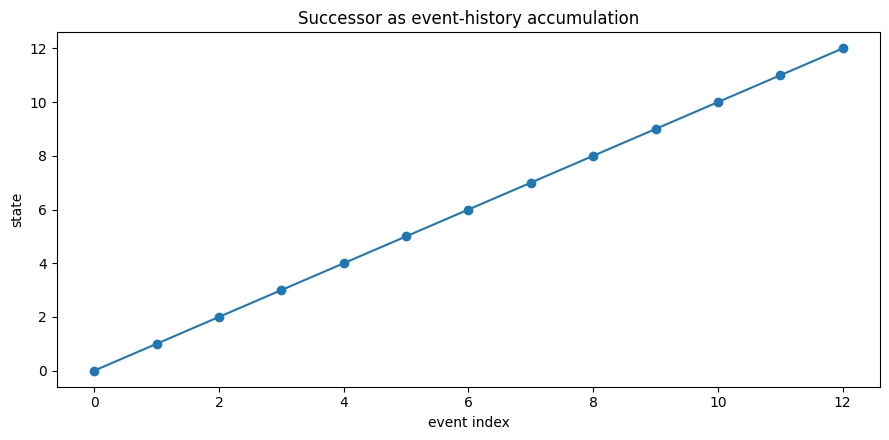

In [5]:

plt.figure(figsize=(9, 4.5))
plt.plot(range(len(xs_unbounded)), xs_unbounded, marker="o")
plt.xlabel("event index")
plt.ylabel("state")
plt.title("Successor as event-history accumulation")
plt.tight_layout()
plt.show()



### Interpretation checkpoint

In the paper, the natural numbers are recovered as repeated successor events:
$$
0,\quad S(0),\quad S^2(0),\quad S^3(0),\dots
$$

So the visible label
$$
n
$$
can be read as the projection of a path of length \(n\) from the origin:
$$
n := S^n(0).
$$

This is the first operator-first move:
the number is **not** primary; the event-history is primary.


## 3. Constraint changes the arithmetic

In [6]:

width = WIDTH_DEFAULT

xs_sat = run_path(saturating_successor, START_STATE, NUM_STEPS, width=width)
xs_mod = run_path(modular_successor, START_STATE, NUM_STEPS, width=width)
xs_res = run_path(reset_successor, START_STATE, NUM_STEPS, width=width, reset_to=0)

print("Saturating path:", xs_sat)
print("Modular path   :", xs_mod)
print("Reset path     :", xs_res)


Saturating path: [0, 1, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Modular path   : [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0]
Reset path     : [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2]


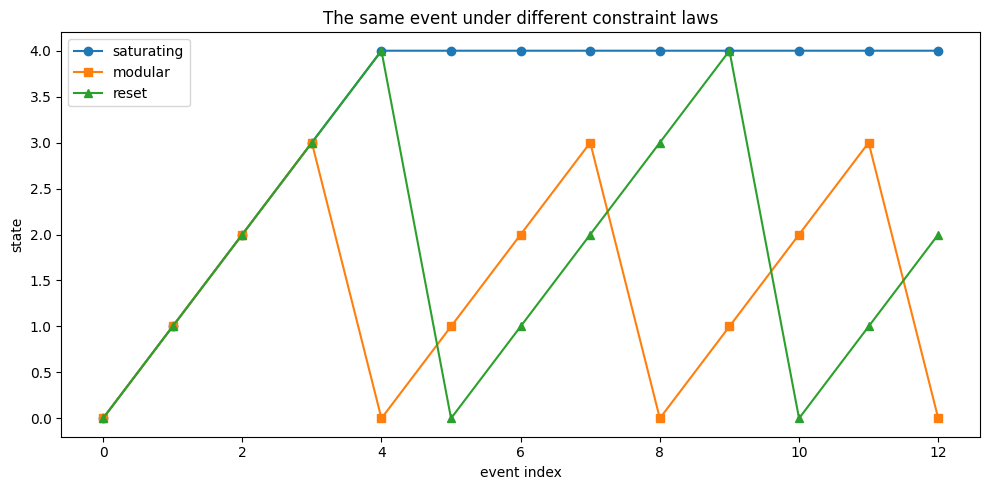

In [7]:

plt.figure(figsize=(10, 5))
plt.plot(range(len(xs_sat)), xs_sat, marker="o", label="saturating")
plt.plot(range(len(xs_mod)), xs_mod, marker="s", label="modular")
plt.plot(range(len(xs_res)), xs_res, marker="^", label="reset")
plt.xlabel("event index")
plt.ylabel("state")
plt.title("The same event under different constraint laws")
plt.legend()
plt.tight_layout()
plt.show()



### Interpretation checkpoint

This is one of the paper's strongest claims:

> **Constraint is part of the number system.**

The same successor-like event can yield different visible arithmetic depending on the box:

- saturating box:
  $$
  x_{t+1}=\min(W,\ x_t+1)
  $$
- rolling box:
  $$
  x_{t+1}=(x_t+1)\bmod W
  $$
- reset box:
  $$
  x_{t+1}=
  \begin{cases}
  x_t+1,& x_t<W\\
  0,& x_t\ge W
  \end{cases}
  $$

So arithmetic is not just event. It is **event under boundary law**.


## 4. The stack as shape and path

In [8]:

def run_stack(instructions):
    depth = 0
    depths = [depth]
    values = []
    log = []

    for ins in instructions:
        if ins[0] == "PUSH":
            values.append(ins[1])
            depth += 1
            log.append((ins, depth, list(values)))
        elif ins[0] == "POP":
            out = values.pop() if values else None
            depth = max(0, depth - 1)
            log.append(((ins[0], out), depth, list(values)))
        elif ins[0] == "ADD":
            if len(values) >= 2:
                b = values.pop()
                a = values.pop()
                values.append(a + b)
            log.append((ins, depth, list(values)))
        elif ins[0] == "SUB":
            if len(values) >= 2:
                b = values.pop()
                a = values.pop()
                values.append(a - b)
            log.append((ins, depth, list(values)))
        depths.append(depth)
    return depths, log

program = [
    ("PUSH", 1),
    ("PUSH", 4),
    ("POP",),
    ("PUSH", 4),
    ("POP",),
    ("PUSH", 1),
    ("ADD",),
]

depths, log = run_stack(program)

print("Execution log:")
for row in log:
    print(row)


Execution log:
(('PUSH', 1), 1, [1])
(('PUSH', 4), 2, [1, 4])
(('POP', 4), 1, [1])
(('PUSH', 4), 2, [1, 4])
(('POP', 4), 1, [1])
(('PUSH', 1), 2, [1, 1])
(('ADD',), 2, [2])


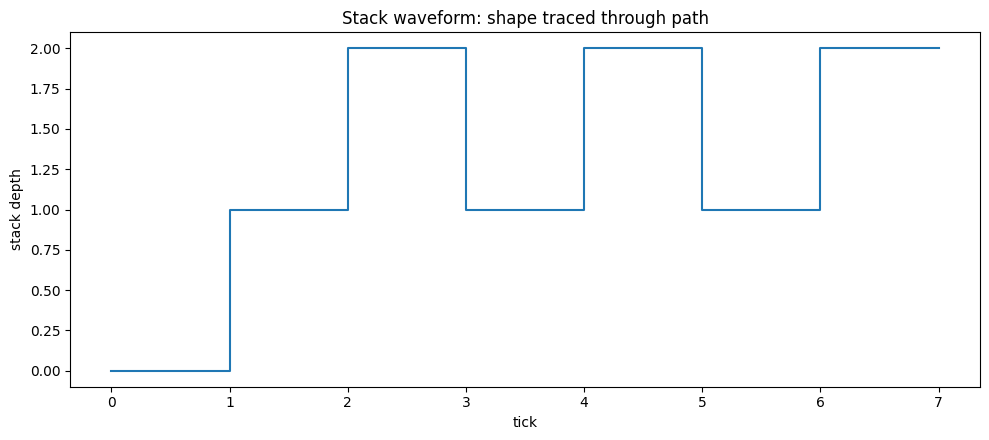

In [9]:

plt.figure(figsize=(10, 4.5))
plt.step(range(len(depths)), depths, where="post")
plt.xlabel("tick")
plt.ylabel("stack depth")
plt.title("Stack waveform: shape traced through path")
plt.tight_layout()
plt.show()



### Interpretation checkpoint

The stack already behaves like a geometric oscillator.

- **shape** = current retained configuration,
- **path** = event history that created that shape.

This is why the paper says the stack is not merely a container of values.  
It is a **geometric history carrier**.

The depth plot is the visible waveform.
The instruction log is the hidden path.


## 5. Addition as path composition

In [10]:

def successor_path(n, x0=0):
    xs = [x0]
    for _ in range(n):
        xs.append(xs[-1] + 1)
    return xs

a = 2
b = 2

path_a = successor_path(a, 0)
path_ab = successor_path(b, path_a[-1])
path_total = successor_path(a + b, 0)

print("Path for a=2 from 0      :", path_a)
print("Then continue by b=2     :", path_ab)
print("Direct path for total=4  :", path_total)
print("Final residues equal?    :", path_ab[-1] == path_total[-1])


Path for a=2 from 0      : [0, 1, 2]
Then continue by b=2     : [2, 3, 4]
Direct path for total=4  : [0, 1, 2, 3, 4]
Final residues equal?    : True



### Interpretation checkpoint

The paper reads
$$
2+2=4
$$
as path composition:
$$
P_C\!\bigl(S^2(S^2(0))\bigr)=P_C\!\bigl(S^4(0)\bigr).
$$

That means equality is not magical identity between nouns.  
It is the statement that two lawful histories collapse to the same residue.


## 6. Equality as path-equivalence

In [11]:

def path_equivalent(path1, path2):
    return path1[-1] == path2[-1]

cases = [
    ("2+2 vs 4", successor_path(2, successor_path(2, 0)[-1]), successor_path(4, 0)),
    ("1+3 vs 4", successor_path(3, successor_path(1, 0)[-1]), successor_path(4, 0)),
    ("3+1 vs 4", successor_path(1, successor_path(3, 0)[-1]), successor_path(4, 0)),
]

for name, p1, p2 in cases:
    print(name, "->", path_equivalent(p1, p2), "| residues:", p1[-1], p2[-1])


2+2 vs 4 -> True | residues: 4 4
1+3 vs 4 -> True | residues: 4 4
3+1 vs 4 -> True | residues: 4 4



### Exercise 6.1

Write, in your own words, what is being claimed when you say:
$$
2+2=4.
$$

Try to explain it two ways:
1. noun-first,
2. path-first.

The paper's claim is that the path-first version is deeper.


## 7. Numerals are not numbers

In [12]:

n = 4
bases = [2, 4, 8, 10]
for base in bases:
    print(f"{n} in base {base} -> {project_base(n, base)}")


4 in base 2 -> 100
4 in base 4 -> 10
4 in base 8 -> 4
4 in base 10 -> 4



### Interpretation checkpoint

The paper makes a strict distinction:

- **number** = collapsed residue of a lawful history
- **numeral** = encoding of that residue in a chosen projection system

So the same residue can appear as:
$$
4,\quad 100_2,\quad 10_4,\quad 4_{10}.
$$

The event-history does not change.
Only the projection code changes.


## 8. Constants as operator stances

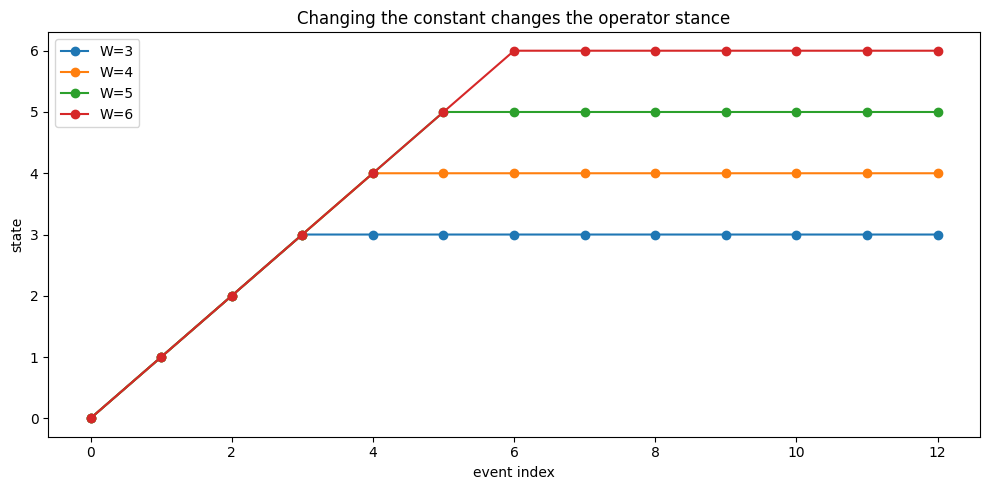

In [13]:

widths = [3, 4, 5, 6]
paths = {W: run_path(saturating_successor, START_STATE, NUM_STEPS, width=W) for W in widths}

plt.figure(figsize=(10, 5))
for W, xs in paths.items():
    plt.plot(range(len(xs)), xs, marker="o", label=f"W={W}")
plt.xlabel("event index")
plt.ylabel("state")
plt.title("Changing the constant changes the operator stance")
plt.legend()
plt.tight_layout()
plt.show()



### Interpretation checkpoint

In this workbook, the width \(W\) is a simple example of a **constant as operator stance**.

It is not just “a number used.”
It selects the closure regime of the system.

That is the paper's broader point:
constants choose *how the event space is shaped*.


## 9. Minimal formal core


The paper's formal proposal can be compressed into the following definitions.

Let:
- \(X\) be a state manifold,
- \(U\) an event alphabet,
- \(C\) a constraint law,
- \(F_C:X\times U\to X\) an update operator,
- \(P_C:X\to Y\) a projection into visible residues,
- \(I_C:X\to \mathcal I\) an invariant extractor.

Then:

### Event-history number
A number in the system \((X,U,C)\) is any residue
$$
n=P_C(x_t)
$$
for some lawful history
$$
x_t=F_C^{(t)}(x_0;u_0,\dots,u_{t-1}).
$$

### Equality
Two histories are equal iff they preserve the same residue:
$$
H_1 \equiv_C H_2
\quad\Longleftrightarrow\quad
P_C(H_1(x_0))=P_C(H_2(x_0)).
$$

### Proof
A proof is a sequence of admissible rewrites preserving the invariant:
$$
I_C(H_i(x_0))=I_C(H_{i+1}(x_0)).
$$


## 10. Workbook prompts


### Prompt A
Explain why the stack is both a **shape** and a **path**.

### Prompt B
Explain why changing the box width changes the arithmetic itself rather than merely changing the output range.

### Prompt C
Explain why numerals are projections rather than the ground entities.

### Prompt D
Explain why the paper says:
$$
\text{proof} = \text{invariant-preserving path rewrite}.
$$


## 11. Optional extension cells


1. Add multiplication as repeated path composition.
2. Add modular stacks with different starting residues.
3. Add weighted events instead of plain successor.
4. Add a comparison between stack depth waveforms and recursive fold traces.
5. Build a bridge notebook from this foundation paper into the SHA transport papers.
